In [1]:
pip install torch torchvision matplotlib

100%|██████████| 9.91M/9.91M [00:00<00:00, 294MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 17.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 149MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.59MB/s]


Epoch 0, Loss 16481.826171875
Epoch 1, Loss 16039.7373046875
Epoch 2, Loss 14847.6552734375


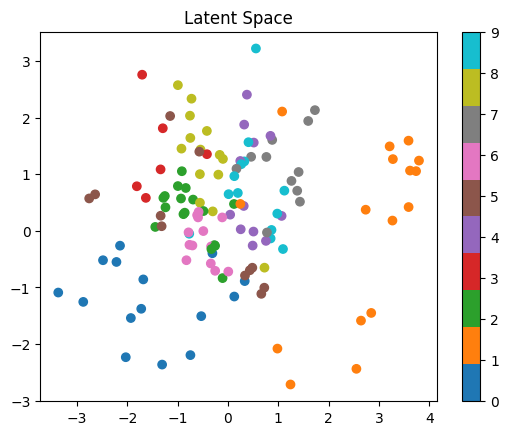

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Load data
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True)

# VAE Model
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 2)  # mean
        self.fc22 = nn.Linear(400, 2)  # logvar
        self.fc3 = nn.Linear(2, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Loss
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Train
for epoch in range(3):
    for data, _ in train_loader:
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_function(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch}, Loss {loss.item()}")

# Latent Space Visualization
import numpy as np
z_points = []
labels = []

for data, label in train_loader:
    mu, _ = model.encode(data.view(-1, 784))
    z_points.append(mu.detach().numpy())
    labels.append(label.numpy())
    break

z = np.concatenate(z_points)
labels = np.concatenate(labels)

plt.scatter(z[:,0], z[:,1], c=labels, cmap='tab10')
plt.colorbar()
plt.title("Latent Space")
plt.show()

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Data
transform = transforms.Compose([transforms.ToTensor()])
loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

G = Generator()
D = Discriminator()

loss_fn = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

# Training
for epoch in range(3):
    for real, _ in loader:
        real = real.view(-1, 784)

        # Train Discriminator
        noise = torch.randn(real.size(0), 100)
        fake = G(noise)

        loss_D = loss_fn(D(real), torch.ones(real.size(0),1)) + \
                 loss_fn(D(fake.detach()), torch.zeros(real.size(0),1))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        loss_G = loss_fn(D(fake), torch.ones(real.size(0),1))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch} Loss D: {loss_D.item()} Loss G: {loss_G.item()}")

Epoch 0 Loss D: 1.052150011062622 Loss G: 0.8106861114501953
Epoch 1 Loss D: 0.9014948606491089 Loss G: 0.9938597083091736
Epoch 2 Loss D: 0.799101710319519 Loss G: 1.5043458938598633


In [4]:
pip install torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.0 MB/s eta 0:00:00


In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# Load dataset (Cora)
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

# GCN Model
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training
for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss {loss.item()}")

# Test accuracy
model.eval()
pred = model(data).argmax(dim=1)
correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())
print("Accuracy:", acc)

Processing...
Done!


Epoch 0, Loss 1.9457526206970215
Epoch 1, Loss 1.8367104530334473
Epoch 2, Loss 1.6960288286209106
Epoch 3, Loss 1.5415445566177368
Epoch 4, Loss 1.4124784469604492
Epoch 5, Loss 1.2646244764328003
Epoch 6, Loss 1.1107035875320435
Epoch 7, Loss 0.9701830148696899
Epoch 8, Loss 0.9046199321746826
Epoch 9, Loss 0.7914144396781921
Epoch 10, Loss 0.7027202844619751
Epoch 11, Loss 0.606032133102417
Epoch 12, Loss 0.525282084941864
Epoch 13, Loss 0.44731754064559937
Epoch 14, Loss 0.4226873815059662
Epoch 15, Loss 0.4022631049156189
Epoch 16, Loss 0.32248616218566895
Epoch 17, Loss 0.2884693443775177
Epoch 18, Loss 0.2991198003292084
Epoch 19, Loss 0.22458620369434357
Epoch 20, Loss 0.2455039918422699
Epoch 21, Loss 0.199125275015831
Epoch 22, Loss 0.16119924187660217
Epoch 23, Loss 0.12663352489471436
Epoch 24, Loss 0.1312156766653061
Epoch 25, Loss 0.13433699309825897
Epoch 26, Loss 0.11943718045949936
Epoch 27, Loss 0.13034331798553467
Epoch 28, Loss 0.10297369956970215
Epoch 29, Loss 0.1